# Demofile Evaluation
Demofile to evaluate the results from the isochrone calculation interactively. Not meant for to reproduce the results of this project but to show how some functions work.  
For easier calculation for multiple days and regions, please use the main.py or evaluation.py file.

In [1]:
import geopandas as gpd
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import shapely

import evaluation as ev
from config import *

In [2]:
# load dataframes if already created

df_areas = pd.read_csv(f"{PATH_OUT_EVALUATION}area.csv")
df_populations = pd.read_csv(f"{PATH_OUT_EVALUATION}population.csv")
df_areas_oerok = pd.read_csv(f"{PATH_OUT_EVALUATION}oerok_area.csv")
df_populations_oerok = pd.read_csv(f"{PATH_OUT_EVALUATION}oerok_population.csv")

In [5]:
# Config:
population_file = "Eurostat_Census-GRID_2021_V2.2/ESTAT_Census_2021_V2.gpkg"
population = None

In [ ]:
# load population data, skip if not wanted to calculate population
population = ev.load_population(population_file)

Loaded population from Eurostat_Census-GRID_2021_V2.2/ESTAT_Census_2021_V2.gpkg ... 40.815s


In [4]:
# calculate areas and population for all days
df_areas, df_populations = ev.create_area_df(ALL_DAYS, population)

display(df_areas)
display(df_populations)

Calculated areas (and population) for 20 days ... 297.641s


,date,A,B,C,D,E,F,G
0,20240131,209.049844,247.054857,481.579445,916.150082,1403.566185,2248.116482,6127.352496
1,20240215,203.371987,240.004236,465.050045,885.121488,1347.764871,2180.614395,5996.810572
2,20240315,208.113204,246.939722,479.195111,910.693623,1397.027856,2239.822540,6106.594599
3,20240415,203.200051,241.367252,464.927210,881.923520,1368.450269,2216.637002,6090.627088
4,20240515,202.367950,240.347868,461.730886,880.500306,1373.756111,2223.468562,6105.000993
5,20240614,202.592587,240.077749,463.928228,886.467772,1385.092058,2236.018649,6129.576967
6,20240715,174.499553,212.657745,414.385154,781.222789,1169.781707,1894.030504,5283.832367
7,20240814,187.367468,223.899355,427.258607,785.973307,1175.663050,1904.082747,5320.134720
8,20240916,234.018887,264.499285,486.433730,900.359220,1393.412505,2254.607092,6217.154600
9,20241015,233.360722,263.943482,486.051987,889.606820,1379.116732,2238.958944,6184.716478


,date,A,B,C,D,E,F,G
0,20240131,1660692,826456,845339,957549,869344,868689,1206899
1,20240215,1638662,813598,840898,945131,854959,858886,1230204
2,20240315,1649665,830441,844407,968728,856655,865581,1208098
3,20240415,1656573,779963,831915,968909,851645,899008,1218198
4,20240515,1656573,775044,838968,965112,850946,901145,1219931
5,20240614,1650596,765098,842568,976494,858865,896382,1222708
6,20240715,1512273,773865,807041,922637,836667,830086,1252961
7,20240814,1563945,830890,833733,888617,804967,800901,1238707
8,20240916,1791491,885710,851854,898267,829201,846332,1193940
9,20241015,1791491,884269,846397,902463,825314,843186,1198079


In [7]:
# calculate areas and population for existing solution from oerok
df_areas_oerok, df_populations_oerok = ev.prepare_oerok_data(day1=OEROK_NAME_SCHEME.format(OEROK_DAYS[0]), 
                                                            day2=OEROK_NAME_SCHEME.format(OEROK_DAYS[1]), population=population)

display(df_areas_oerok)
display(df_populations_oerok)

Loaded and calculated oerok data for OeV_Gueteklassen_Polygone_20241023.shp and OeV_Gueteklassen_Polygone_20241030.shp ... 52.778s


,date,A,B,C,D,E,F,G
0,20241023,144.581486,271.054423,504.562119,927.776294,1523.491529,2523.461925,6024.800330
1,20241030,132.895361,241.419674,453.877192,809.871834,1249.634285,2088.590148,5095.896749


,date,A,B,C,D,E,F,G
0,20241023,1291543,1114949,934909,947075,923782,880666,1187509
1,20241030,1208893,1120005,871349,912508,862526,834390,1175224


In [4]:
df_stats = ev.statistics(df_areas, df_populations)

display(df_stats)

Calculated simple statistics for 18 days ... 0.014s


,type,statistic,day,A,B,C,D,E,F,G,total
0,area,avg,weekday,2.101164e+02,245.676097,466.629797,872.752194,1340.047276,2166.249643,5.973954e+03,1.127543e+04
1,area,avg,weekend,1.096555e+02,140.377555,247.582848,467.814059,673.647700,1084.124603,3.318620e+03,6.041822e+03
2,area,max,weekday,2.407805e+02,267.933665,494.653411,916.150082,1403.566185,2266.444610,6.290752e+03,1.185159e+04
3,area,max,weekend,1.355118e+02,168.282861,294.442628,538.389030,780.421407,1220.718790,3.604689e+03,6.689551e+03
4,area,min,weekday,1.744996e+02,212.657745,414.385154,781.222789,1169.781707,1894.030504,5.283832e+03,9.930410e+03
5,area,min,weekend,8.944660e+01,118.928311,203.784096,390.751945,568.006919,927.171368,2.945090e+03,5.243179e+03
6,area,std,weekday,1.956525e+01,16.651038,23.954918,44.746834,83.034446,132.957192,3.335301e+02,6.418258e+02
7,area,std,weekend,1.828211e+01,18.619610,37.854274,65.715922,93.979431,137.815930,3.079396e+02,6.728580e+02
0,population,avg,weekday,1.678309e+06,829746.666667,838309.000000,930910.500000,839598.750000,854205.333333,1.217014e+06,7.188094e+06
1,population,avg,weekend,1.158656e+06,813396.166667,625122.333333,733855.333333,662269.333333,737739.833333,1.226782e+06,5.957821e+06


In [ ]:
# OPTIONAL: save created dataframes

df_areas.to_csv(f"{PATH_OUT_EVALUATION}area.csv", index=False)
df_populations.to_csv(f"{PATH_OUT_EVALUATION}population.csv", index=False)
df_areas_oerok.to_csv(f"{PATH_OUT_EVALUATION}oerok_area.csv", index=False)
df_populations_oerok.to_csv(f"{PATH_OUT_EVALUATION}oerok_population.csv", index=False)

df_stats.to_csv(f"{PATH_OUT_EVALUATION}statistics.csv", index=False)

In [3]:
# total area/pop calculation for already created dfs, not needed when running all fresh

# df_areas['total'] = df_areas.iloc[:,1:].sum(axis=1)
# df_populations['total'] = df_populations.iloc[:,1:].sum(axis=1)

# df_areas_oerok['total'] = df_areas_oerok.iloc[:,1:].sum(axis=1)
# df_populations_oerok['total'] = df_populations_oerok.iloc[:,1:].sum(axis=1)

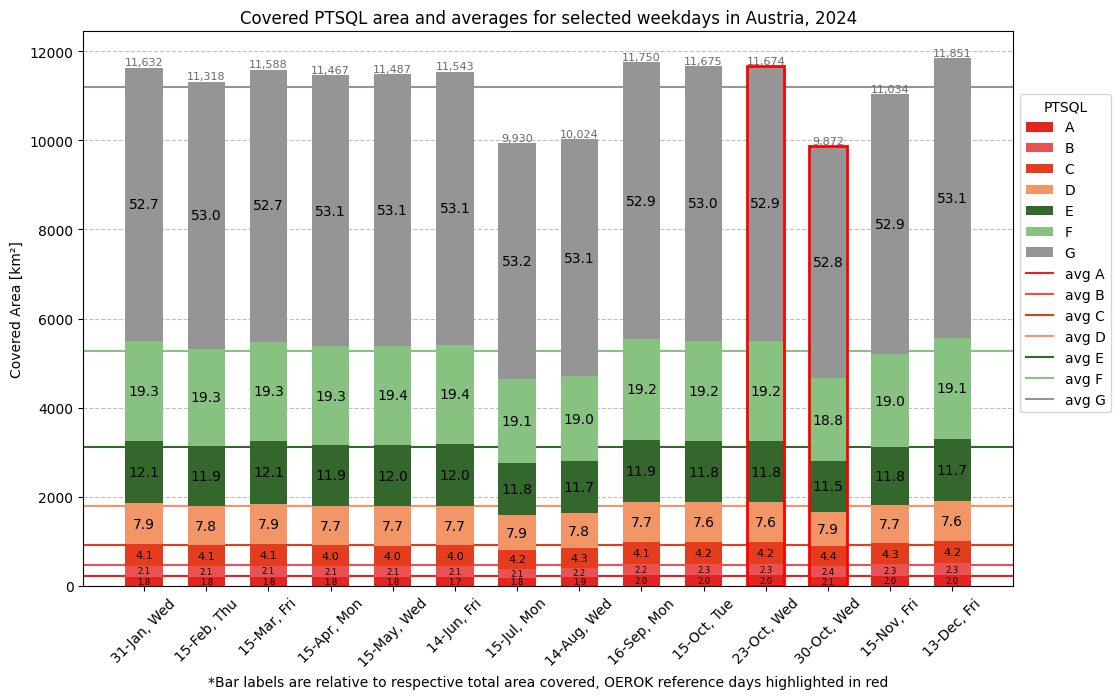

In [3]:
p_new = ev.create_time_series_plot(df_areas, days=WEEKDAYS + OEROK_DAYS, type="area", day_names=True, 
                            plot_size='auto', bar_labels=True, percentages=True, rotate_bar_labels=False, 
                            title="Covered PTSQL area and averages for selected weekdays in Austria, 2024", show_totals=True, avg_lines=True, highlight=OEROK_DAYS)

p_new[1].set_xlabel("*Bar labels are relative to respective total area covered, OEROK reference days highlighted in red")
plt.show()

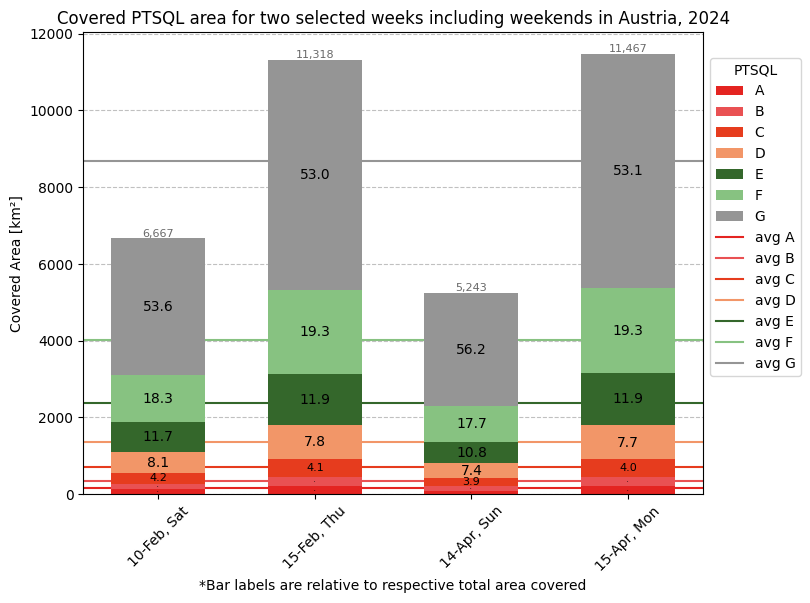

In [5]:
p_new2 = ev.create_time_series_plot(df_areas, days=[20240210, 20240215, 20240414, 20240415], type="area", day_names=True, 
                            plot_size=(8,6), bar_labels=True, percentages=True, rotate_bar_labels=False, 
                            title="Covered PTSQL area for two selected weeks including weekends in Austria, 2024", show_totals=True, avg_lines=True,)

p_new2[1].set_xlabel("*Bar labels are relative to respective total area covered")
plt.show()

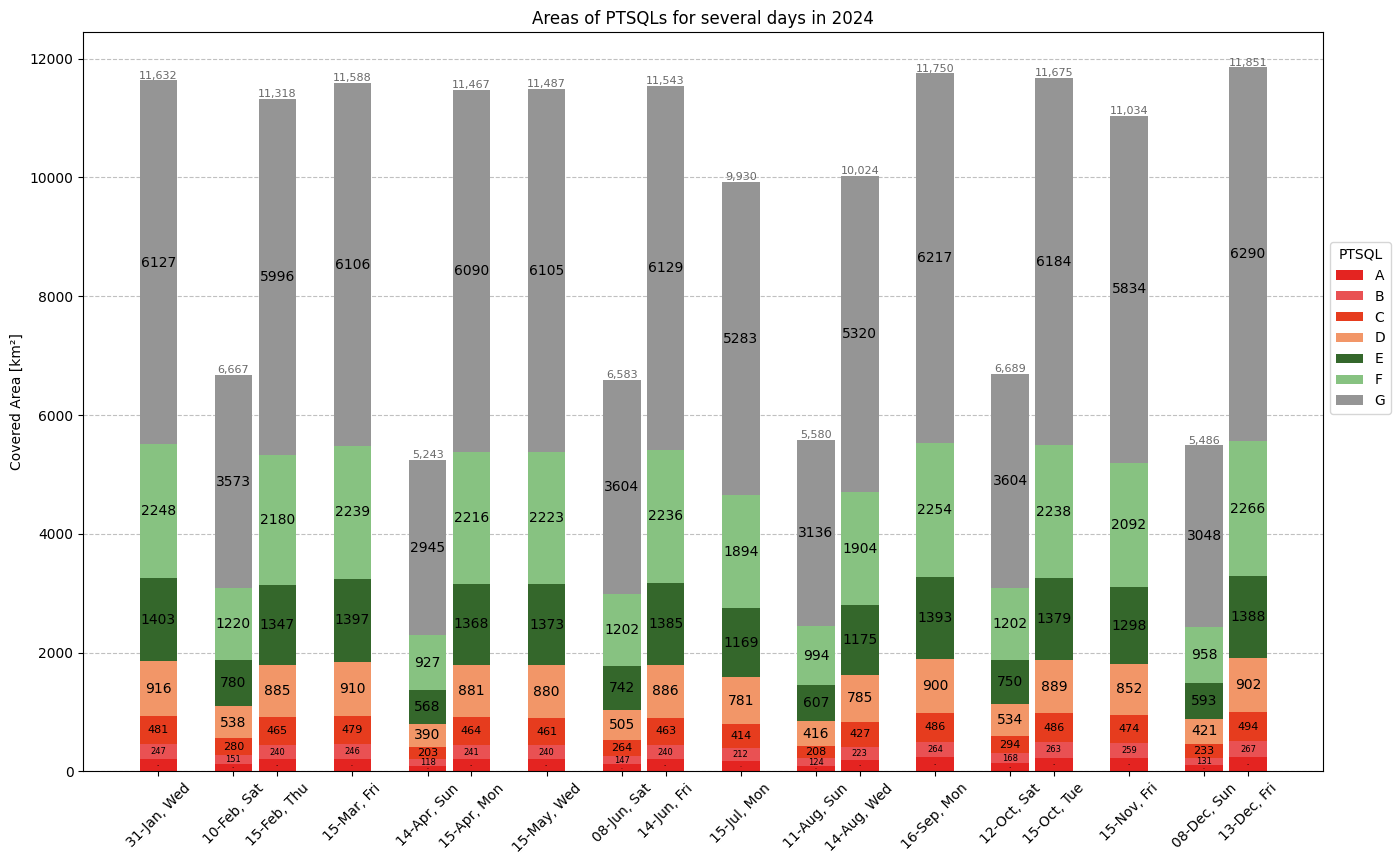

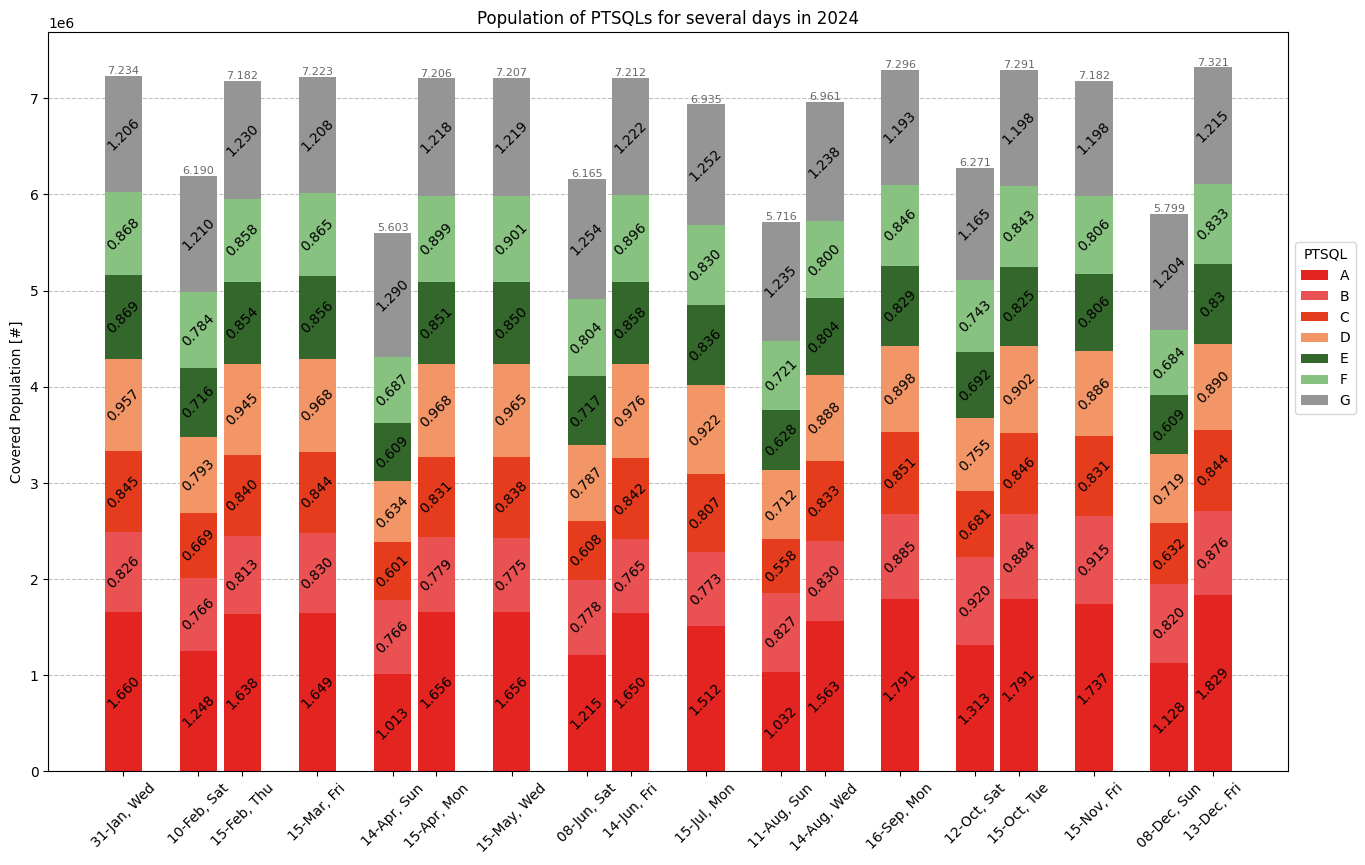

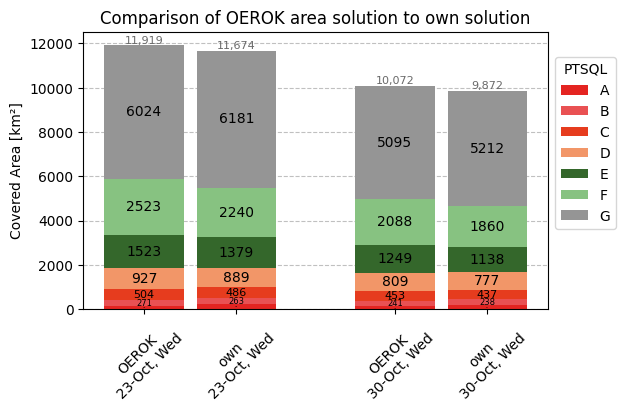

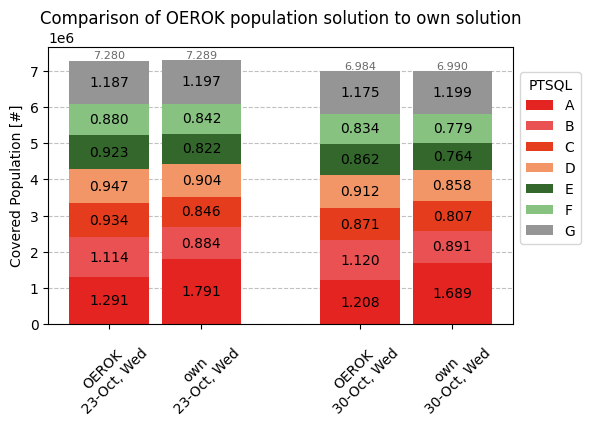

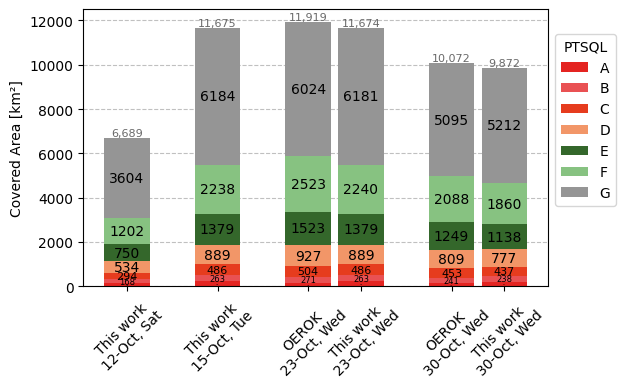

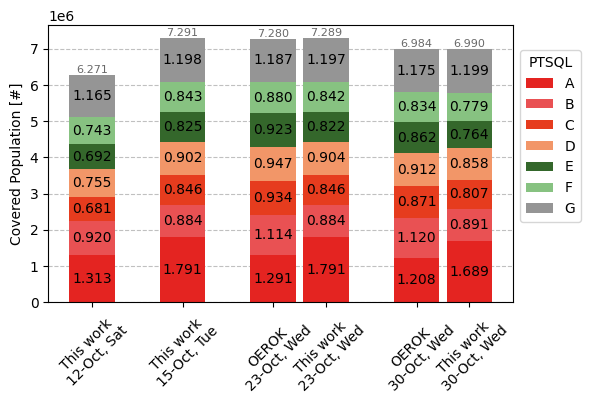

In [6]:
# create evaluation plots

p3 = ev.create_time_series_plot(df_areas, days=WEEKDAYS + WEEKENDS, type="area", day_names=True, 
                            plot_size='auto', bar_labels=True, groupby='month', rotate_bar_labels=False, 
                            title="Areas of PTSQLs for several days in 2024",)

p4 = ev.create_time_series_plot(df_populations, days=WEEKDAYS + WEEKENDS, type="population", day_names=True, 
                            plot_size='auto', bar_labels=True, groupby='month', rotate_bar_labels=True,
                            title="Population of PTSQLs for several days in 2024",)

df_a = pd.concat([df_areas_oerok, df_areas], axis=0)
df_p = pd.concat([df_populations_oerok, df_populations], axis=0)

custom_labels = ["OEROK", "own", "OEROK", "own"]

p5 = ev.create_time_series_plot(df_a, days=OEROK_DAYS, type="area", day_names=True, plot_size='auto',
                            bar_labels=True, groupby='day', custom_labels=custom_labels,
                            title="Comparison of OEROK area solution to own solution")  

p6 = ev.create_time_series_plot(df_p, days=OEROK_DAYS, type="population", day_names=True, plot_size='auto',
                            bar_labels=True, groupby='day', custom_labels=custom_labels,
                            title="Comparison of OEROK population solution to own solution")

custom_labels = ["This work", "This work", "OEROK", "This work", "OEROK", "This work"]

p7 = ev.create_time_series_plot(df_a, days=OEROK_DAYS + OTHER_DAYS, type="area", day_names=True, plot_size='auto',
                            bar_labels=True, groupby='day', custom_labels=custom_labels,)
                            #custom_title="Comparison of OEROK area solution to other days")  

p8 = ev.create_time_series_plot(df_p, days=OEROK_DAYS + OTHER_DAYS, type="population", day_names=True, plot_size='auto',
                            bar_labels=True, groupby='day', custom_labels=custom_labels)
                            #custom_title="Comparison of OEROK population solution to other days")

In [5]:
# OPTIONAL: save plots
p3.savefig(f"{PATH_OUT_FIGS}area.png", bbox_inches='tight')
p4.savefig(f"{PATH_OUT_FIGS}population.png", bbox_inches='tight')
p5.savefig(f"{PATH_OUT_FIGS}oerok_area.png", bbox_inches='tight')
p6.savefig(f"{PATH_OUT_FIGS}oerok_population.png", bbox_inches='tight')
p7.savefig(f"{PATH_OUT_FIGS}oerok_area_other_days.png", bbox_inches='tight')
p8.savefig(f"{PATH_OUT_FIGS}oerok_population_other_days.png", bbox_inches='tight')